# I used gemini to help me formulate an error method using euler's method to get the local error at each step, and then store that error to be plotted at each step for h = 0.1 to 1.5

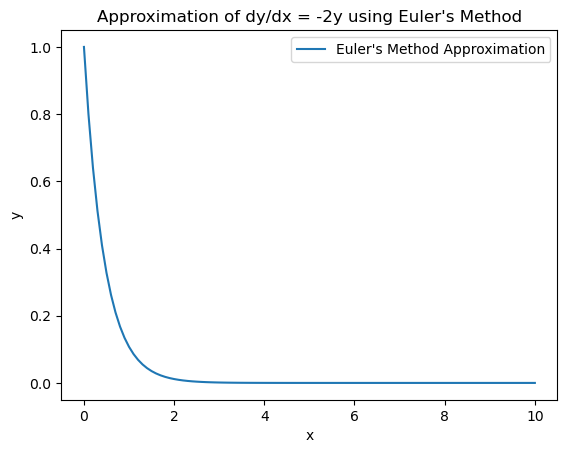

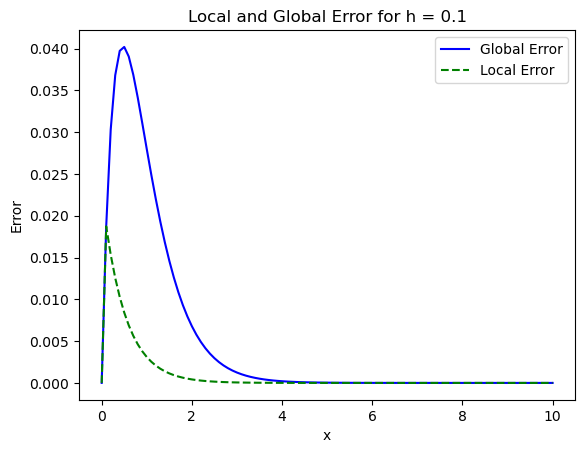

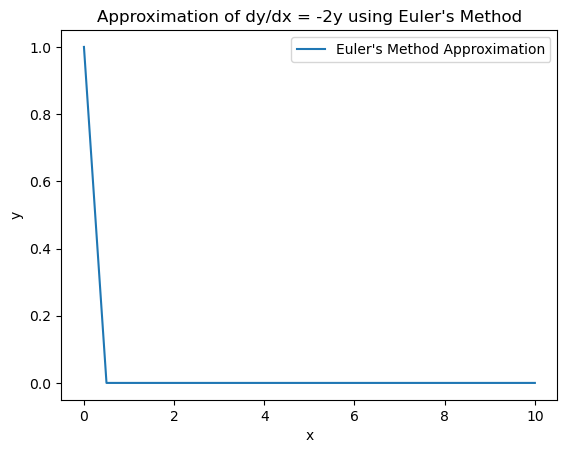

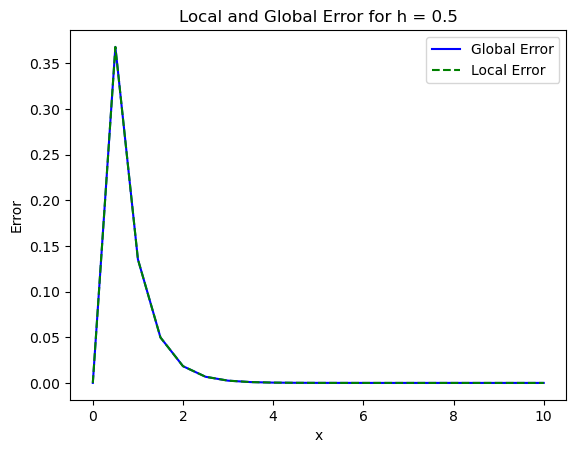

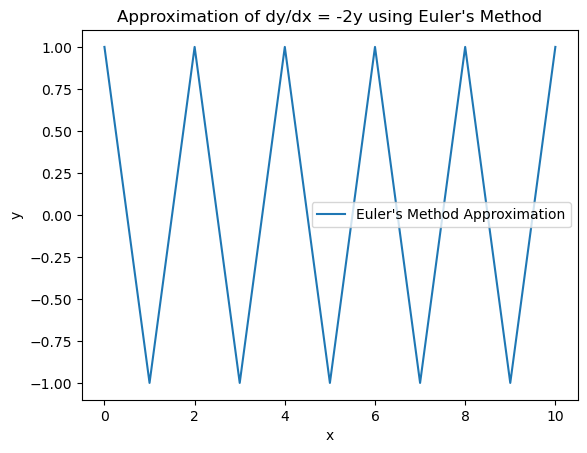

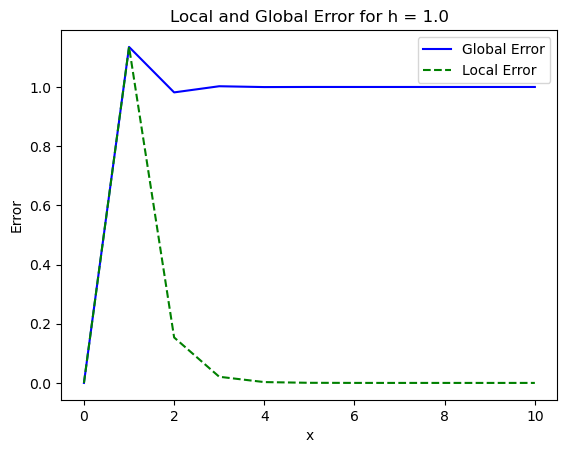

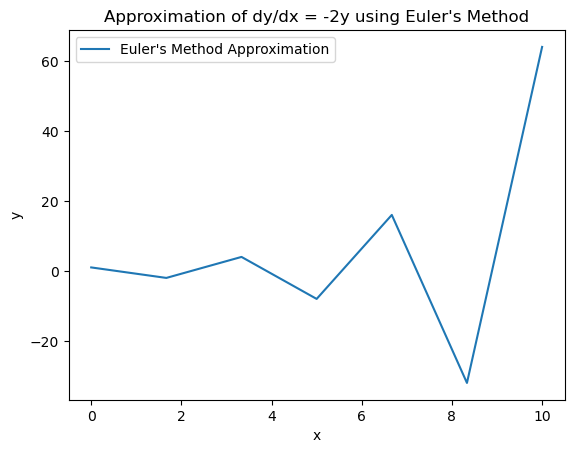

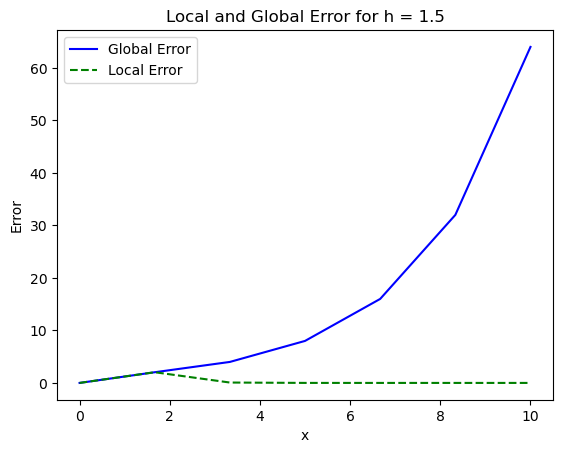

In [7]:
import numpy as np
import matplotlib.pyplot as plt
# Define parameters
h = np.array([0.1, 0.5, 1.0, 1.5], dtype="float") # step size
x_start, x_end = 0, 10
# Function representing dy/dx = -2y
def f(x, y):
    return -2 * y

#Exact function
def exactsol(x):
    return np.exp(-2*x)

# Euler's method and error analysis
for val in h:
    #initialization
    num_steps = int((x_end - x_start) / val)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    # Initial condition
    y_values[0] = 1 # y(0) = 1

    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + val * f(x_values[i], y_values[i])
    # Plot the results
    plt.plot(x_values, y_values, label="Euler's Method Approximation")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title("Approximation of dy/dx = -2y using Euler's Method")
    plt.legend()
    plt.show()

    #calculate global error
    y_exact = exactsol(x_values)
    global_error = np.abs(y_exact - y_values)

    #calculate local error
    local_error = np.zeros(num_steps + 1)
    for i in range(num_steps):
        y_exact_start = exactsol(x_values[i])
        y_step = y_exact_start + val * f(x_values[i], y_exact_start)
        local_error[i + 1] = np.abs(exactsol(x_values[i + 1]) - y_step)

    #plot both errors
    plt.plot(x_values, global_error, label="Global Error", color='b')
    plt.plot(x_values, local_error, label="Local Error", color='g', linestyle='--')
    plt.xlabel('x')
    plt.ylabel('Error')
    plt.title(f"Local and Global Error for h = {val}")
    plt.legend()
    plt.show()